# Notebook 2 — Diversidad beta taxonómica

Calcula Bray-Curtis, PCoA, NMDS y PERMANOVA. Todas las gráficas se guardan en `plots/`.

In [1]:
# Instalación de dependencias (ejecutar si es necesario)
# En Google Colab o un ambiente limpio, descomenta la siguiente línea:
!pip install pandas numpy scipy scikit-bio seaborn matplotlib statsmodels openpyxl xlrd scikit-learn

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

ALL_SAMPLES_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/all_samples.tsv"
METADATA_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/metadata_cibimi.csv"
FUNCTION_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/output_all_levels_and_function.csv"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def save_current_fig(filename, dpi=300):
    """Guarda la figura actual dentro de plots/ y la muestra."""
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Figura guardada en: {path}")
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 85.8 MB/s eta 0:00:00


## 1. Carga y preparación de datos

In [2]:
def load_metadata(url=METADATA_URL):
    metadata = pd.read_csv(url)
    metadata = metadata.rename(columns={"MBI Sample ID": "SampleID"})
    metadata["SampleID"] = metadata["SampleID"].astype(str).str.strip()
    metadata = metadata.set_index("SampleID")
    if "Week" in metadata.columns:
        metadata["Week"] = pd.to_numeric(metadata["Week"], errors="coerce")
    if "Baby number" in metadata.columns:
        metadata["Baby number"] = metadata["Baby number"].astype(str)
    return metadata

def clean_sample_id(sample_name):
    return str(sample_name).split("_")[0].strip()

def load_otu_table(url=ALL_SAMPLES_URL):
    # El archivo all_samples.tsv incluye una primera línea extra en algunos exports de biom.
    otu = pd.read_csv(url, sep="\t", skiprows=1)
    otu = otu.rename(columns={"#OTU ID": "OTU_ID"})
    if "OTU_ID" not in otu.columns:
        otu = pd.read_csv(url, sep="\t")
        otu = otu.rename(columns={"#OTU ID": "OTU_ID"})
    if "Consensus Lineage" not in otu.columns:
        raise ValueError("No se encontró la columna 'Consensus Lineage' en all_samples.tsv")
    otu = otu.set_index("OTU_ID")
    sample_cols = [c for c in otu.columns if c != "Consensus Lineage"]
    counts = otu[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0).T
    counts.index = [clean_sample_id(i) for i in counts.index]
    counts = counts.groupby(counts.index).sum()
    taxonomy = otu["Consensus Lineage"].copy()
    return counts, taxonomy, otu

def align_counts_metadata(counts, metadata):
    common = counts.index.intersection(metadata.index)
    counts_aligned = counts.loc[common].copy()
    metadata_aligned = metadata.loc[common].copy()
    print(f"Muestras usadas: {counts_aligned.shape[0]}")
    print(f"Features/ASVs: {counts_aligned.shape[1]}")
    return counts_aligned, metadata_aligned

metadata = load_metadata()
otu_counts, taxonomy, otu_raw = load_otu_table()
otu_counts, metadata = align_counts_metadata(otu_counts, metadata)
metadata.head()

Muestras usadas: 83
Features/ASVs: 10794


,Your Sample ID,Baby number,Sampling Date,Weeks of gestation,Sample Type,Group,Sex,Weight,Size,Head Circunference,Abdominal Circunference,Necrotizing enterocolitis,Type of Birth,Clasification birth weight,Week
S00SO-0001,C3.1,3,Week 1 (Birth),27.0,human feces,CONTROL,fem,800.0,34.0,24.0,18.0,No presence,Cesarean,Extremely low,1
S00SO-0002,C3.2,3,Week 2,NaN,human feces,CONTROL,fem,805.0,34.0,23.0,18.0,No presence,Cesarean,Extremely low,2
S00SO-0003,C3.3,3,Week 3,NaN,human feces,CONTROL,fem,870.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,3
S00SO-0004,C3.4,3,Week 4,NaN,human feces,CONTROL,fem,910.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,4
S00SO-0005,C3.5,3,Week 5,NaN,human feces,CONTROL,fem,NaN,NaN,NaN,NaN,No presence,Cesarean,Extremely low,5


## 2. Matriz Bray-Curtis

In [3]:
from skbio.diversity import beta_diversity
from skbio import DistanceMatrix

bray = beta_diversity(metric="braycurtis", counts=otu_counts.values, ids=otu_counts.index)
bray_df = bray.to_data_frame()
bray_df.to_csv("beta_diversity_braycurtis.csv")
bray_df.head()

,S00SO-0001,S00SO-0002,S00SO-0003,S00SO-0004,S00SO-0005,S00SO-0006,S00SO-0007,S00SO-0008,S00SO-0009,S00SO-0010,...,S00SO-0076,S00SO-0077,S00SO-0078,S00SO-0079,S00SO-0080,S00SO-0081,S00SO-0082,S00SO-0083,S00SO-0084,S00SO-0086
S00SO-0001,0.000000,0.974040,0.994789,0.996204,0.995417,0.612614,0.745241,0.996053,0.994333,0.527405,...,0.841225,0.917719,0.995673,0.402656,0.551597,0.995658,0.995785,0.276336,0.732222,0.993063
S00SO-0002,0.974040,0.000000,0.993237,0.995144,0.993858,0.975586,0.954884,0.993388,0.993171,0.987721,...,0.988840,0.836223,0.955410,0.976015,0.986700,0.993297,0.993929,0.974705,0.937610,0.992457
S00SO-0003,0.994789,0.993237,0.000000,0.207896,0.138880,0.993513,0.993582,0.448970,0.296297,0.995648,...,0.995918,0.994407,0.991613,0.993582,0.994829,0.924889,0.914391,0.995254,0.994987,0.980222
S00SO-0004,0.996204,0.995144,0.207896,0.000000,0.159594,0.995578,0.995561,0.496253,0.388911,0.996947,...,0.996786,0.996119,0.992774,0.995227,0.996393,0.931695,0.915901,0.996952,0.996742,0.971593
S00SO-0005,0.995417,0.993858,0.138880,0.159594,0.000000,0.994246,0.994531,0.403502,0.343906,0.996544,...,0.996607,0.994302,0.989452,0.994060,0.995534,0.928774,0.915269,0.995978,0.995418,0.970226


## 3. PCoA

Figura guardada en: plots/beta_pcoa_braycurtis_group.png


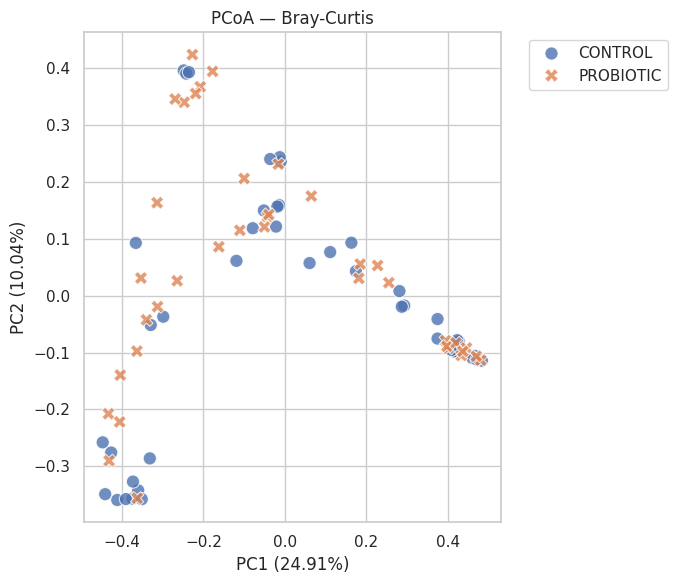

In [4]:
from skbio.stats.ordination import pcoa

pcoa_results = pcoa(bray)
pcoa_df = pcoa_results.samples.iloc[:, :2].join(metadata)
pcoa_df.to_csv("pcoa_braycurtis_scores.csv")

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pcoa_df, x="PC1", y="PC2", hue="Group", style="Group", s=90, alpha=0.8)
plt.xlabel(f"PC1 ({pcoa_results.proportion_explained.iloc[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pcoa_results.proportion_explained.iloc[1]*100:.2f}%)")
plt.title("PCoA — Bray-Curtis")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
save_current_fig("beta_pcoa_braycurtis_group.png")

## 4. NMDS

Figura guardada en: plots/beta_nmds_braycurtis_group.png


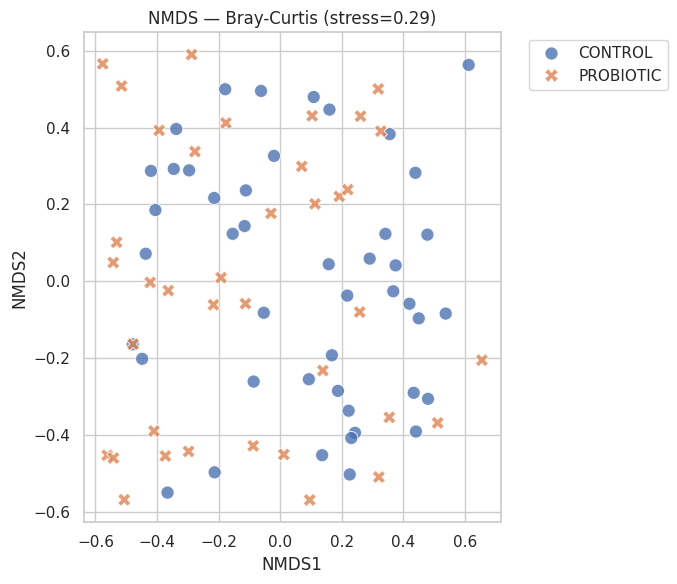

In [5]:
from sklearn.manifold import MDS

nmds = MDS(n_components=2, metric=False, dissimilarity="precomputed", random_state=RANDOM_SEED, n_init=10, max_iter=3000)
coords = nmds.fit_transform(bray_df.values)
nmds_df = pd.DataFrame(coords, columns=["NMDS1", "NMDS2"], index=bray_df.index).join(metadata)
nmds_df.to_csv("nmds_braycurtis_scores.csv")

plt.figure(figsize=(7, 6))
sns.scatterplot(data=nmds_df, x="NMDS1", y="NMDS2", hue="Group", style="Group", s=90, alpha=0.8)
plt.title(f"NMDS — Bray-Curtis (stress={nmds.stress_:.2f})")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
save_current_fig("beta_nmds_braycurtis_group.png")

## 8. NMDS coloreada por Fecha de Muestreo y estilo por Grupo

Figura guardada en: plots/beta_nmds_braycurtis_sampling_date_group.png


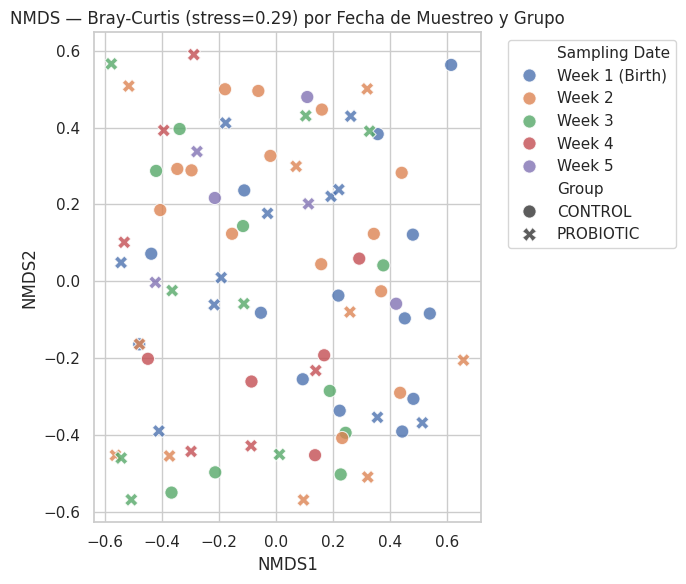

In [6]:
sampling_date_col = "Sampling Date"
group_col = "Group"

if sampling_date_col in nmds_df.columns and group_col in nmds_df.columns:
    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=nmds_df, x="NMDS1", y="NMDS2", hue=sampling_date_col, style=group_col, s=90, alpha=0.8)
    plt.title(f"NMDS — Bray-Curtis (stress={nmds.stress_:.2f}) por Fecha de Muestreo y Grupo")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    save_current_fig("beta_nmds_braycurtis_sampling_date_group.png")
else:
    print(f"No se encontraron las columnas '{sampling_date_col}' o '{group_col}' en nmds_df.")

## 9. NMDS coloreada por Número de Bebé y estilo por Grupo

Figura guardada en: plots/beta_nmds_braycurtis_weekly_trajectories_group_colored.png


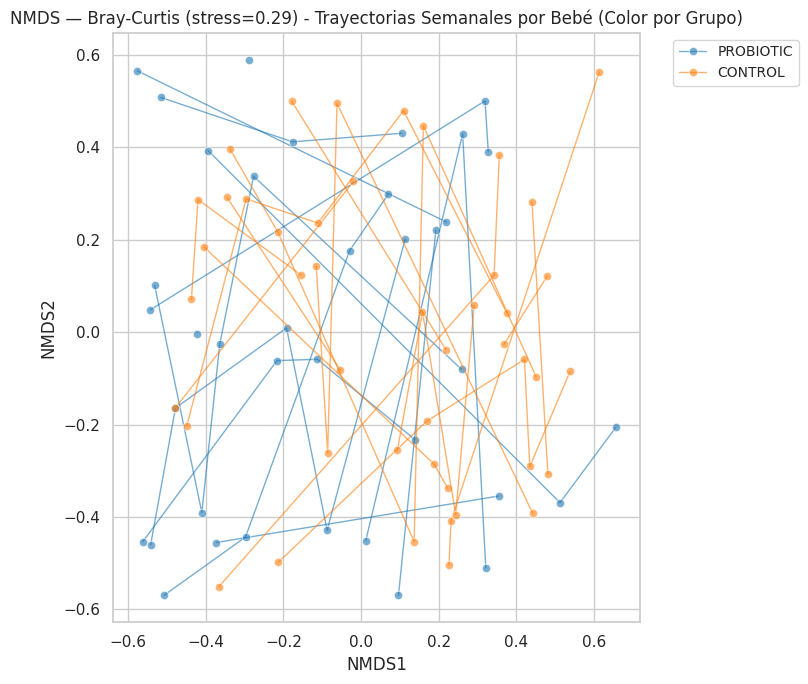

In [7]:
baby_number_col = "Baby number"
group_col = "Group"
week_col = "Week"

if baby_number_col in nmds_df.columns and group_col in nmds_df.columns and week_col in nmds_df.columns:
    # Filter out NaNs in 'Week' and sort to ensure correct line drawing for trajectories
    nmds_df_trajectories = nmds_df.dropna(subset=[week_col]).sort_values(by=[baby_number_col, week_col])

    plt.figure(figsize=(8, 7))
    sns.lineplot(
        data=nmds_df_trajectories,
        x="NMDS1", y="NMDS2",
        hue=group_col,         # Color by group
        units=baby_number_col, # Draw a separate line for each baby (trajectory)
        marker="o",            # Show individual points along the trajectory
        linewidth=1,           # Small lines
        alpha=0.6,             # Tenuous lines
        linestyle="-",         # Solid lines for trajectories
        legend="full",
        palette="tab10"        # A good palette for distinct groups
    )
    plt.title(f"NMDS — Bray-Curtis (stress={nmds.stress_:.2f}) - Trayectorias Semanales por Bebé (Color por Grupo)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize='small', ncol=1)
    save_current_fig("beta_nmds_braycurtis_weekly_trajectories_group_colored.png")
else:
    print(f"No se encontraron las columnas '{baby_number_col}', '{group_col}' o '{week_col}' en nmds_df.")

## 5. PERMANOVA por grupo

In [8]:
from skbio.stats.distance import permanova

if "Group" in metadata.columns:
    permanova_res = permanova(bray, metadata["Group"], permutations=999)
    print(permanova_res)
else:
    print("No se encontró la columna Group en metadata.")

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      83
number of groups                  2
test statistic             1.322674
p-value                       0.192
number of permutations          999
Name: PERMANOVA results, dtype: object


## 6. PCoA coloreada por NEC

Figura guardada en: plots/beta_pcoa_braycurtis_nec.png


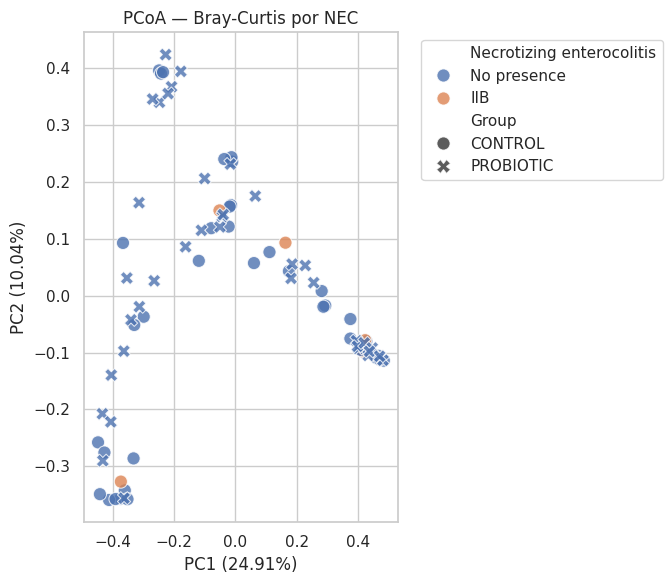

In [9]:
nec_col = "Necrotizing enterocolitis"
if nec_col in pcoa_df.columns:
    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=pcoa_df, x="PC1", y="PC2", hue=nec_col, style="Group", s=90, alpha=0.8)
    plt.xlabel(f"PC1 ({pcoa_results.proportion_explained.iloc[0]*100:.2f}%)")
    plt.ylabel(f"PC2 ({pcoa_results.proportion_explained.iloc[1]*100:.2f}%)")
    plt.title("PCoA — Bray-Curtis por NEC")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    save_current_fig("beta_pcoa_braycurtis_nec.png")

## 7. PCoA coloreada por Fecha de Muestreo

Figura guardada en: plots/beta_pcoa_braycurtis_sampling_date.png


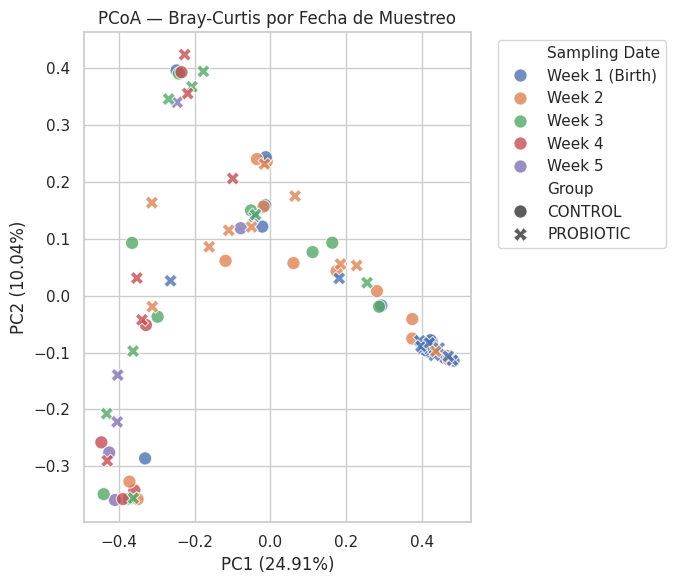

In [10]:
sampling_date_col = "Sampling Date"
if sampling_date_col in pcoa_df.columns:
    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=pcoa_df, x="PC1", y="PC2", hue=sampling_date_col, style="Group", s=90, alpha=0.8)
    plt.xlabel(f"PC1 ({pcoa_results.proportion_explained.iloc[0]*100:.2f}%)")
    plt.ylabel(f"PC2 ({pcoa_results.proportion_explained.iloc[1]*100:.2f}%)")
    plt.title("PCoA — Bray-Curtis por Fecha de Muestreo")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    save_current_fig("beta_pcoa_braycurtis_sampling_date.png")
else:
    print(f"No se encontró la columna '{sampling_date_col}' en pcoa_df.")